  Email No.  the  to  ect  and  for  of    a  you  hou  ...  connevey  jay  \
0   Email 1    0   0    1    0    0   0    2    0    0  ...         0    0   
1   Email 2    8  13   24    6    6   2  102    1   27  ...         0    0   
2   Email 3    0   0    1    0    0   0    8    0    0  ...         0    0   
3   Email 4    0   5   22    0    5   1   51    2   10  ...         0    0   
4   Email 5    7   6   17    1    5   2   57    0    9  ...         0    0   

   valued  lay  infrastructure  military  allowing  ff  dry  Prediction  
0       0    0               0         0         0   0    0           0  
1       0    0               0         0         0   1    0           0  
2       0    0               0         0         0   0    0           0  
3       0    0               0         0         0   0    0           0  
4       0    0               0         0         0   1    0           0  

[5 rows x 3002 columns]
[0 0 1 ... 0 1 0]


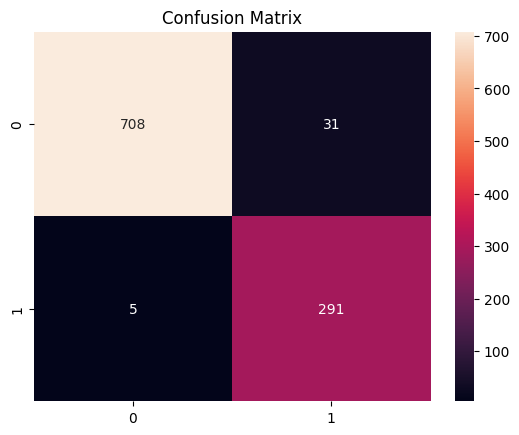

Accuracy :0.9652
Precision score :0.9037
Recall Score :0.9831
F1 score :0.9417


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

#Loading the data set
data = pd.read_csv('emails.csv')

print(data.head())

# Dropping the Email.No column if it exists
if 'Email No.' in data.columns:
    data = data.drop(columns=['Email No.'])

# Check if there are any remaining non-numeric columns
non_numeric_cols = data.select_dtypes(include=['object']).columns
if len(non_numeric_cols) > 0:
    print(f"Non-numeric columns found: {non_numeric_cols}")
    # Convert categorical columns using one-hot encoding
    data = pd.get_dummies(data, columns=non_numeric_cols)

# Splitting features and the target
X = data.drop('Prediction', axis=1)
y = data['Prediction']

# Spiltting the data set into training and testing data sets
X_train, X_test, y_train, y_test =train_test_split(X, y, test_size=0.2, random_state= 42)

# Applying StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Training the model
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(y_pred)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.show()

 # Evaluating metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy :{accuracy:.4f}")

precision = precision_score(y_test, y_pred)
print(f"Precision score :{precision:.4f}")
recall = recall_score(y_test, y_pred)
print(f"Recall Score :{recall:.4f}")

f1 = f1_score(y_test, y_pred)
print(f"F1 score :{f1:.4f}")
